# Построение моделей

# Загрузка данных

In [1]:
import numpy as np
import random
import warnings
warnings.filterwarnings('ignore')

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

In [2]:
import os

os.chdir("..")

In [3]:
import pandas as pd

df = pd.read_parquet("data/processed/model_dataset.parquet")
df.head()

,date_block_num,year,month,item_cnt_month,avg_price,lag_1,lag_2,lag_3,lag_6,lag_12,...,month_sin,month_cos,is_summer,is_winter,days_in_month,shop_id_target_enc,item_id_target_enc,item_category_id_target_enc,main_category_target_enc,super_category_target_enc
0,13,2014,2,0.0,119.0,1.0,0.0,0.0,0.0,0.0,...,0.866025,0.5,0,1,28,0.170076,2.479303,0.259266,0.223939,0.223939
1,13,2014,2,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.866025,0.5,0,1,28,0.246914,0.000000,0.165687,0.223939,0.223939
2,13,2014,2,1.0,1699.0,0.0,2.0,0.0,0.0,0.0,...,0.866025,0.5,0,1,28,0.283779,0.256410,0.323786,0.291757,0.291757
3,13,2014,2,0.0,199.0,0.0,1.0,1.0,1.0,0.0,...,0.866025,0.5,0,1,28,0.544732,0.175321,0.225952,0.208121,0.208121
4,13,2014,2,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.866025,0.5,0,1,28,0.234513,0.000000,0.225952,0.208121,0.208121


# Разделение выборки

In [4]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def expanding_month_split(X, date_col='date_block_num', min_train_months=1):
    """
    Генератор расширяющегося временного окна.
    На каждом шаге train – все месяцы от начала до текущего, test – следующий месяц.
    """
    X_sorted = X.sort_values(date_col)
    dates = X_sorted[date_col].values
    unique_dates = np.unique(dates)
    unique_dates.sort()
    total_months = len(unique_dates)
    
    for train_end_idx in range(min_train_months, total_months - 1):
        train_months = unique_dates[:train_end_idx + 1]
        test_month = unique_dates[train_end_idx + 1]
        train_idx = np.where(np.isin(dates, train_months))[0]
        test_idx = np.where(dates == test_month)[0]
        yield train_idx, test_idx


def evaluate_model_cv(model_class, params, X, y, splitter):
    """
    Оценивает модель на временной кросс-валидации.
    Возвращает средние RMSE, MAE, R² и списки по фолдам.
    """
    rmse_list = []
    mae_list = []
    r2_list = []
    
    for train_idx, test_idx in splitter:
        X_train = X.iloc[train_idx].drop(columns=['date_block_num'])
        X_test = X.iloc[test_idx].drop(columns=['date_block_num'])
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        
        model = model_class(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        rmse_list.append(np.sqrt(mean_squared_error(y_test, preds)))
        mae_list.append(mean_absolute_error(y_test, preds))
        r2_list.append(r2_score(y_test, preds))
    
    return (np.mean(rmse_list), np.mean(mae_list), np.mean(r2_list),
            rmse_list, mae_list, r2_list)

In [5]:
X = df.drop(columns=['item_cnt_month'])
y = df['item_cnt_month']

# Минимальное число месяцев в обучающей выборке – 10 (для стабильности)
splitter = list(expanding_month_split(X, date_col='date_block_num', min_train_months=10))
print(f"Количество фолдов: {len(splitter)}")

Количество фолдов: 10


# Модели

## MLFlow

In [6]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Model_Comparison")

<Experiment: artifact_location='file:///d:/Глеб/Pet-projects/dynamic-pricing-system/mlruns/1', creation_time=1785171886684, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785171886684, lifecycle_stage='active', name='Model_Comparison', tags={}, trace_location=None, workspace='default'>

## Модели

In [7]:
from catboost import CatBoostRegressor
import lightgbm as lgb
import xgboost as xgb

baseline_params = {
    'CatBoost': {
        'iterations': 500,
        'learning_rate': 0.1,
        'depth': 6,
        'loss_function': 'RMSE',
        'verbose': False,
        'task_type': 'GPU',
        'devices': '0',
        'random_state': SEED
    },
    'LightGBM': {
        'n_estimators': 500,
        'learning_rate': 0.1,
        'num_leaves': 31,
        'verbose': -1,
        'device': 'cpu',
        'gpu_platform_id': 0,
        'gpu_device_id': 0,
        'seed': SEED
    },
    'XGBoost': {
        'n_estimators': 500,
        'learning_rate': 0.1,
        'max_depth': 6,
        'verbosity': 0,
        'tree_method': 'hist',
        'device': 'cuda',
        'seed': SEED
    }
}

model_classes = {
    'CatBoost': CatBoostRegressor,
    'LightGBM': lgb.LGBMRegressor,
    'XGBoost': xgb.XGBRegressor
}

In [8]:
baseline_results = {}

for name in ['CatBoost', 'LightGBM', 'XGBoost']:
    with mlflow.start_run(run_name=f"{name}_baseline_gpu") as run:
        params = baseline_params[name]
        mlflow.log_params(params)
        
        avg_rmse, avg_mae, avg_r2, rmse_list, mae_list, r2_list = evaluate_model_cv(
            model_classes[name], params, X, y, splitter
        )
        
        mlflow.log_metric("cv_avg_rmse", avg_rmse)
        mlflow.log_metric("cv_avg_mae", avg_mae)
        mlflow.log_metric("cv_avg_r2", avg_r2)
        
        for i, (rmse, mae, r2) in enumerate(zip(rmse_list, mae_list, r2_list)):
            mlflow.log_metric(f"fold_{i}_rmse", rmse)
            mlflow.log_metric(f"fold_{i}_mae", mae)
            mlflow.log_metric(f"fold_{i}_r2", r2)
        
        print(f"{name} baseline RMSE: {avg_rmse:.4f}, MAE: {avg_mae:.4f}, R²: {avg_r2:.4f}")
        baseline_results[name] = avg_rmse

best_baseline = min(baseline_results, key=baseline_results.get)
print(f"\nЛучшая baseline модель: {best_baseline} с RMSE = {baseline_results[best_baseline]:.4f}")

CatBoost baseline RMSE: 0.8475, MAE: 0.1723, R²: 0.6223
LightGBM baseline RMSE: 0.8772, MAE: 0.1686, R²: 0.5904
XGBoost baseline RMSE: 0.8659, MAE: 0.1725, R²: 0.6041

Лучшая baseline модель: CatBoost с RMSE = 0.8475


mlflow ui --backend-store-uri sqlite:///mlflow.db


## Optuna

In [9]:
def objective(trial):
    params = get_optuna_params(trial, model_name)
    avg_rmse, _, _, _, _, _ = evaluate_model_cv(
        model_classes[model_name], params, X, y, splitter
    )
    return avg_rmse

In [10]:
import optuna

def get_optuna_params(trial, model_name):
    if model_name == 'CatBoost':
        return {
            'iterations': trial.suggest_int('iterations', 300, 1500, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'loss_function': 'RMSE',
            'verbose': False,
            'task_type': 'GPU',
            'devices': '0',
            'random_state': SEED
        }
    elif model_name == 'LightGBM':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1500, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'verbose': -1,
            'device': 'cpu',
            'gpu_platform_id': 0,
            'gpu_device_id': 0,
            'seed': SEED
        }
    elif model_name == 'XGBoost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1500, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'verbosity': 0,
            'device': 'cuda',
            'seed': SEED
        }

top_models = sorted(baseline_results, key=baseline_results.get)[:2]
print(f"Модели для оптимизации: {top_models}")

mlflow.set_experiment("Model_Optuna")

best_params_dict = {}

for model_name in top_models:
    n_trials = 50 if model_name == best_baseline else 30
    
    def objective(trial):
        params = get_optuna_params(trial, model_name)
        avg_rmse, _, _, _, _, _ = evaluate_model_cv(
            model_classes[model_name], params, X, y, splitter
        )
        return avg_rmse
    
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    best_params = study.best_params
    best_rmse = study.best_value
    
    # Логирование в MLflow
    with mlflow.start_run(run_name=f"{model_name}_optuna_full") as run:
        mlflow.log_params(best_params)
        
        avg_rmse, avg_mae, avg_r2, rmse_list, mae_list, r2_list = evaluate_model_cv(
            model_classes[model_name], best_params, X, y, splitter
        )
        
        mlflow.log_metric("cv_avg_rmse", avg_rmse)
        mlflow.log_metric("cv_avg_mae", avg_mae)
        mlflow.log_metric("cv_avg_r2", avg_r2)
        
        for i, (rmse, mae, r2) in enumerate(zip(rmse_list, mae_list, r2_list)):
            mlflow.log_metric(f"fold_{i}_rmse", rmse)
            mlflow.log_metric(f"fold_{i}_mae", mae)
            mlflow.log_metric(f"fold_{i}_r2", r2)
        
        mlflow.log_metric("best_trial_rmse", best_rmse)
        
        for i, trial in enumerate(study.trials):
            if trial.value is not None:
                mlflow.log_metric(f"trial_{i}_rmse", trial.value, step=i)
        
        print(f"{model_name} optimized - RMSE: {avg_rmse:.4f}, MAE: {avg_mae:.4f}, R²: {avg_r2:.4f}")
    
    best_params_dict[model_name] = best_params
    print(f"Best params for {model_name}: {best_params}")

[I 2026-07-28 18:22:56,042] A new study created in memory with name: no-name-0f60eae5-8dda-4eb0-b38e-4de4fa2e476d


Модели для оптимизации: ['CatBoost', 'XGBoost']


Best trial: 0. Best value: 0.882873:   2%|▏         | 1/50 [03:05<2:31:34, 185.59s/it]

[I 2026-07-28 18:26:01,634] Trial 0 finished with value: 0.8828728379805311 and parameters: {'iterations': 700, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 0.24810409748678125, 'border_count': 66}. Best is trial 0 with value: 0.8828728379805311.


Best trial: 1. Best value: 0.846547:   4%|▍         | 2/50 [06:02<2:24:31, 180.66s/it]

[I 2026-07-28 18:28:58,849] Trial 1 finished with value: 0.8465471077372498 and parameters: {'iterations': 500, 'learning_rate': 0.012184186502221764, 'depth': 10, 'l2_leaf_reg': 0.2537815508265665, 'border_count': 190}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:   6%|▌         | 3/50 [07:30<1:48:14, 138.18s/it]

[I 2026-07-28 18:30:26,483] Trial 2 finished with value: 0.8923735644883936 and parameters: {'iterations': 300, 'learning_rate': 0.2708160864249968, 'depth': 9, 'l2_leaf_reg': 0.0070689749506246055, 'border_count': 72}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:   8%|▊         | 4/50 [09:14<1:35:39, 124.78s/it]

[I 2026-07-28 18:32:10,710] Trial 3 finished with value: 0.8483664287848374 and parameters: {'iterations': 500, 'learning_rate': 0.028145092716060652, 'depth': 7, 'l2_leaf_reg': 0.05342937261279776, 'border_count': 97}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:  10%|█         | 5/50 [11:59<1:44:28, 139.31s/it]

[I 2026-07-28 18:34:55,775] Trial 4 finished with value: 0.8494113253468705 and parameters: {'iterations': 1000, 'learning_rate': 0.01607123851203988, 'depth': 6, 'l2_leaf_reg': 0.029204338471814112, 'border_count': 134}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:  12%|█▏        | 6/50 [15:48<2:04:29, 169.77s/it]

[I 2026-07-28 18:38:44,675] Trial 5 finished with value: 0.8574692779392349 and parameters: {'iterations': 1300, 'learning_rate': 0.019721610970574007, 'depth': 7, 'l2_leaf_reg': 0.23423849847112907, 'border_count': 42}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:  14%|█▍        | 7/50 [17:51<1:50:40, 154.42s/it]

[I 2026-07-28 18:40:47,507] Trial 6 finished with value: 0.8653146715369576 and parameters: {'iterations': 1000, 'learning_rate': 0.0178601378893971, 'depth': 4, 'l2_leaf_reg': 6.245139574743075, 'border_count': 248}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:  16%|█▌        | 8/50 [20:23<1:47:33, 153.65s/it]

[I 2026-07-28 18:43:19,509] Trial 7 finished with value: 0.8528514142344413 and parameters: {'iterations': 1300, 'learning_rate': 0.028180680291847244, 'depth': 4, 'l2_leaf_reg': 0.5456725485601477, 'border_count': 130}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:  18%|█▊        | 9/50 [21:19<1:24:10, 123.19s/it]

[I 2026-07-28 18:44:15,721] Trial 8 finished with value: 0.8575606332462208 and parameters: {'iterations': 400, 'learning_rate': 0.05388108577817234, 'depth': 4, 'l2_leaf_reg': 4.337920697490942, 'border_count': 89}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:  20%|██        | 10/50 [24:49<1:40:00, 150.00s/it]

[I 2026-07-28 18:47:45,752] Trial 9 finished with value: 0.850151168591843 and parameters: {'iterations': 1100, 'learning_rate': 0.028869220380495747, 'depth': 7, 'l2_leaf_reg': 0.1537592023548176, 'border_count': 73}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:  22%|██▏       | 11/50 [32:49<2:43:02, 250.84s/it]

[I 2026-07-28 18:55:45,235] Trial 10 finished with value: 0.8618966627107276 and parameters: {'iterations': 1500, 'learning_rate': 0.10809366764261572, 'depth': 10, 'l2_leaf_reg': 0.0011799062523159324, 'border_count': 250}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 1. Best value: 0.846547:  24%|██▍       | 12/50 [35:16<2:18:50, 219.22s/it]

[I 2026-07-28 18:58:12,140] Trial 11 finished with value: 0.8499525276250923 and parameters: {'iterations': 600, 'learning_rate': 0.01033252223104203, 'depth': 8, 'l2_leaf_reg': 0.04237355153892447, 'border_count': 197}. Best is trial 1 with value: 0.8465471077372498.


Best trial: 12. Best value: 0.834898:  26%|██▌       | 13/50 [38:37<2:11:56, 213.96s/it]

[I 2026-07-28 19:01:34,002] Trial 12 finished with value: 0.834898107503429 and parameters: {'iterations': 600, 'learning_rate': 0.04465378952492726, 'depth': 10, 'l2_leaf_reg': 0.8851428264797501, 'border_count': 183}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  28%|██▊       | 14/50 [43:01<2:17:21, 228.92s/it]

[I 2026-07-28 19:05:57,495] Trial 13 finished with value: 0.8433032261946675 and parameters: {'iterations': 800, 'learning_rate': 0.06473018353923564, 'depth': 10, 'l2_leaf_reg': 1.3360887476798675, 'border_count': 186}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  30%|███       | 15/50 [47:41<2:22:29, 244.26s/it]

[I 2026-07-28 19:10:37,291] Trial 14 finished with value: 0.8383605383072531 and parameters: {'iterations': 800, 'learning_rate': 0.07451312958351382, 'depth': 10, 'l2_leaf_reg': 1.438494697238285, 'border_count': 189}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  32%|███▏      | 16/50 [52:01<2:21:07, 249.05s/it]

[I 2026-07-28 19:14:57,477] Trial 15 finished with value: 0.847610693589869 and parameters: {'iterations': 800, 'learning_rate': 0.10819902951346513, 'depth': 10, 'l2_leaf_reg': 2.4433433117837593, 'border_count': 156}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  34%|███▍      | 17/50 [55:46<2:13:01, 241.88s/it]

[I 2026-07-28 19:18:42,664] Trial 16 finished with value: 0.8396666993310722 and parameters: {'iterations': 800, 'learning_rate': 0.05243256118117049, 'depth': 9, 'l2_leaf_reg': 0.953336360110449, 'border_count': 221}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  36%|███▌      | 18/50 [58:29<1:56:20, 218.15s/it]

[I 2026-07-28 19:21:25,589] Trial 17 finished with value: 0.8401296641886891 and parameters: {'iterations': 700, 'learning_rate': 0.08700251256511506, 'depth': 8, 'l2_leaf_reg': 9.057056981390064, 'border_count': 167}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  38%|███▊      | 19/50 [1:02:38<1:57:29, 227.42s/it]

[I 2026-07-28 19:25:34,586] Trial 18 finished with value: 0.8560202206084568 and parameters: {'iterations': 900, 'learning_rate': 0.17557729053316903, 'depth': 9, 'l2_leaf_reg': 2.3258250925034902, 'border_count': 215}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  40%|████      | 20/50 [1:05:02<1:41:14, 202.49s/it]

[I 2026-07-28 19:27:58,985] Trial 19 finished with value: 0.8412264836016753 and parameters: {'iterations': 600, 'learning_rate': 0.07179419498096033, 'depth': 8, 'l2_leaf_reg': 0.6517229228552093, 'border_count': 152}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  42%|████▏     | 21/50 [1:11:28<2:04:24, 257.41s/it]

[I 2026-07-28 19:34:24,430] Trial 20 finished with value: 0.842756459440241 and parameters: {'iterations': 1200, 'learning_rate': 0.044066187799494075, 'depth': 10, 'l2_leaf_reg': 0.07428862633288655, 'border_count': 223}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  44%|████▍     | 22/50 [1:15:13<1:55:32, 247.57s/it]

[I 2026-07-28 19:38:09,067] Trial 21 finished with value: 0.8384399233793329 and parameters: {'iterations': 800, 'learning_rate': 0.0441648596785656, 'depth': 9, 'l2_leaf_reg': 0.9894919548843535, 'border_count': 224}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  46%|████▌     | 23/50 [1:19:24<1:51:58, 248.82s/it]

[I 2026-07-28 19:42:20,791] Trial 22 finished with value: 0.8374062695161006 and parameters: {'iterations': 900, 'learning_rate': 0.03751968994479517, 'depth': 9, 'l2_leaf_reg': 2.3302754837551, 'border_count': 205}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  48%|████▊     | 24/50 [1:24:48<1:57:37, 271.44s/it]

[I 2026-07-28 19:47:45,012] Trial 23 finished with value: 0.8361928453275838 and parameters: {'iterations': 1000, 'learning_rate': 0.03464007059043222, 'depth': 10, 'l2_leaf_reg': 2.489344794812818, 'border_count': 172}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  50%|█████     | 25/50 [1:29:23<1:53:32, 272.48s/it]

[I 2026-07-28 19:52:19,909] Trial 24 finished with value: 0.8399669779630834 and parameters: {'iterations': 1000, 'learning_rate': 0.03729900309582561, 'depth': 9, 'l2_leaf_reg': 3.7486344797351183, 'border_count': 169}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  52%|█████▏    | 26/50 [1:33:56<1:49:02, 272.60s/it]

[I 2026-07-28 19:56:52,793] Trial 25 finished with value: 0.8402549577765056 and parameters: {'iterations': 1200, 'learning_rate': 0.0345671960481455, 'depth': 8, 'l2_leaf_reg': 0.4619007046587843, 'border_count': 136}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  54%|█████▍    | 27/50 [1:38:49<1:46:50, 278.71s/it]

[I 2026-07-28 20:01:45,757] Trial 26 finished with value: 0.8375052822498994 and parameters: {'iterations': 900, 'learning_rate': 0.023338189748455616, 'depth': 10, 'l2_leaf_reg': 2.6430499275591943, 'border_count': 202}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  56%|█████▌    | 28/50 [1:43:44<1:43:56, 283.47s/it]

[I 2026-07-28 20:06:40,328] Trial 27 finished with value: 0.8389337506859892 and parameters: {'iterations': 1100, 'learning_rate': 0.03733647496796239, 'depth': 9, 'l2_leaf_reg': 9.889303352158507, 'border_count': 178}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  58%|█████▊    | 29/50 [1:47:03<1:30:24, 258.31s/it]

[I 2026-07-28 20:09:59,945] Trial 28 finished with value: 0.8478345353621328 and parameters: {'iterations': 1500, 'learning_rate': 0.05752330272044489, 'depth': 5, 'l2_leaf_reg': 1.7887284711458136, 'border_count': 109}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  60%|██████    | 30/50 [1:50:23<1:20:13, 240.68s/it]

[I 2026-07-28 20:13:19,482] Trial 29 finished with value: 0.8696105055512868 and parameters: {'iterations': 600, 'learning_rate': 0.19024182447263455, 'depth': 10, 'l2_leaf_reg': 0.29726781581271594, 'border_count': 205}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  62%|██████▏   | 31/50 [1:53:09<1:09:06, 218.26s/it]

[I 2026-07-28 20:16:05,440] Trial 30 finished with value: 0.8449683630020486 and parameters: {'iterations': 700, 'learning_rate': 0.023291250516610774, 'depth': 8, 'l2_leaf_reg': 0.11983198010113467, 'border_count': 234}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  64%|██████▍   | 32/50 [1:58:01<1:12:05, 240.31s/it]

[I 2026-07-28 20:20:57,180] Trial 31 finished with value: 0.8402371037989053 and parameters: {'iterations': 900, 'learning_rate': 0.025400757119140298, 'depth': 10, 'l2_leaf_reg': 3.825574719313465, 'border_count': 200}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  66%|██████▌   | 33/50 [2:02:12<1:08:59, 243.49s/it]

[I 2026-07-28 20:25:08,114] Trial 32 finished with value: 0.8414282699551693 and parameters: {'iterations': 900, 'learning_rate': 0.02071625566030532, 'depth': 9, 'l2_leaf_reg': 2.535437259179828, 'border_count': 175}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  68%|██████▊   | 34/50 [2:08:09<1:14:01, 277.62s/it]

[I 2026-07-28 20:31:05,371] Trial 33 finished with value: 0.8406660461958279 and parameters: {'iterations': 1100, 'learning_rate': 0.0156757587617279, 'depth': 10, 'l2_leaf_reg': 0.749819377772863, 'border_count': 156}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  70%|███████   | 35/50 [2:10:07<57:28, 229.90s/it]  

[I 2026-07-28 20:33:03,919] Trial 34 finished with value: 0.8453031204638725 and parameters: {'iterations': 400, 'learning_rate': 0.03330168128513806, 'depth': 9, 'l2_leaf_reg': 5.108008640990345, 'border_count': 205}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  72%|███████▏  | 36/50 [2:14:00<53:48, 230.63s/it]

[I 2026-07-28 20:36:56,251] Trial 35 finished with value: 0.839769719767675 and parameters: {'iterations': 700, 'learning_rate': 0.04134292082611553, 'depth': 10, 'l2_leaf_reg': 0.36151464172973424, 'border_count': 234}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  74%|███████▍  | 37/50 [2:18:38<53:05, 245.07s/it]

[I 2026-07-28 20:41:35,020] Trial 36 finished with value: 0.8427784264319881 and parameters: {'iterations': 1000, 'learning_rate': 0.014522615778122453, 'depth': 9, 'l2_leaf_reg': 0.012000726500059275, 'border_count': 190}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  76%|███████▌  | 38/50 [2:20:27<40:48, 204.02s/it]

[I 2026-07-28 20:43:23,256] Trial 37 finished with value: 0.8451421987085661 and parameters: {'iterations': 300, 'learning_rate': 0.030700283274701645, 'depth': 10, 'l2_leaf_reg': 1.44303189552397, 'border_count': 144}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  78%|███████▊  | 39/50 [2:24:37<39:57, 217.95s/it]

[I 2026-07-28 20:47:33,715] Trial 38 finished with value: 0.8421585239857465 and parameters: {'iterations': 900, 'learning_rate': 0.02166556281851711, 'depth': 9, 'l2_leaf_reg': 2.6475479424243487, 'border_count': 207}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  80%|████████  | 40/50 [2:27:24<33:45, 202.58s/it]

[I 2026-07-28 20:50:20,420] Trial 39 finished with value: 0.841061528428142 and parameters: {'iterations': 500, 'learning_rate': 0.04663948163927786, 'depth': 10, 'l2_leaf_reg': 5.871779611255164, 'border_count': 163}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  82%|████████▏ | 41/50 [2:30:36<29:54, 199.39s/it]

[I 2026-07-28 20:53:32,361] Trial 40 finished with value: 0.8452407562638433 and parameters: {'iterations': 1200, 'learning_rate': 0.026000873189216227, 'depth': 6, 'l2_leaf_reg': 0.17175729935836528, 'border_count': 124}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  84%|████████▍ | 42/50 [2:35:26<30:12, 226.52s/it]

[I 2026-07-28 20:58:22,197] Trial 41 finished with value: 0.8435995719672198 and parameters: {'iterations': 900, 'learning_rate': 0.08034917027923512, 'depth': 10, 'l2_leaf_reg': 1.2366639791706058, 'border_count': 184}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  86%|████████▌ | 43/50 [2:40:46<29:42, 254.69s/it]

[I 2026-07-28 21:03:42,622] Trial 42 finished with value: 0.8422676440200437 and parameters: {'iterations': 1000, 'learning_rate': 0.06294562426458673, 'depth': 10, 'l2_leaf_reg': 0.6650560530604034, 'border_count': 191}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  88%|████████▊ | 44/50 [2:44:36<24:44, 247.37s/it]

[I 2026-07-28 21:07:32,912] Trial 43 finished with value: 0.8462019681151197 and parameters: {'iterations': 700, 'learning_rate': 0.10872671724948889, 'depth': 10, 'l2_leaf_reg': 1.7200444349485038, 'border_count': 237}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  90%|█████████ | 45/50 [2:48:19<19:59, 239.83s/it]

[I 2026-07-28 21:11:15,144] Trial 44 finished with value: 0.8402177670560451 and parameters: {'iterations': 800, 'learning_rate': 0.0502430248632426, 'depth': 9, 'l2_leaf_reg': 3.2203296180119083, 'border_count': 179}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  92%|█████████▏| 46/50 [2:54:09<18:12, 273.15s/it]

[I 2026-07-28 21:17:06,031] Trial 45 finished with value: 0.8534505773316866 and parameters: {'iterations': 1100, 'learning_rate': 0.0906177029503522, 'depth': 10, 'l2_leaf_reg': 0.0011000027119649881, 'border_count': 214}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  94%|█████████▍| 47/50 [2:56:59<12:06, 242.11s/it]

[I 2026-07-28 21:19:55,711] Trial 46 finished with value: 0.8390919845160141 and parameters: {'iterations': 500, 'learning_rate': 0.03031121389980809, 'depth': 10, 'l2_leaf_reg': 0.45241543961942465, 'border_count': 195}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  96%|█████████▌| 48/50 [2:59:55<07:24, 222.09s/it]

[I 2026-07-28 21:22:51,093] Trial 47 finished with value: 0.8461652263698023 and parameters: {'iterations': 600, 'learning_rate': 0.017755964512072387, 'depth': 9, 'l2_leaf_reg': 0.9748559793751527, 'border_count': 169}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898:  98%|█████████▊| 49/50 [3:05:23<04:13, 253.97s/it]

[I 2026-07-28 21:28:19,464] Trial 48 finished with value: 0.8440422778709941 and parameters: {'iterations': 1000, 'learning_rate': 0.012637124713745361, 'depth': 10, 'l2_leaf_reg': 6.8414008679386775, 'border_count': 255}. Best is trial 12 with value: 0.834898107503429.


Best trial: 12. Best value: 0.834898: 100%|██████████| 50/50 [3:08:40<00:00, 226.40s/it]


[I 2026-07-28 21:31:36,244] Trial 49 finished with value: 0.8427447483333287 and parameters: {'iterations': 700, 'learning_rate': 0.03912614911118861, 'depth': 8, 'l2_leaf_reg': 1.7054166022055968, 'border_count': 183}. Best is trial 12 with value: 0.834898107503429.
0:	learn: 1.7076611	total: 576ms	remaining: 5m 45s
1:	learn: 1.6649922	total: 1.1s	remaining: 5m 30s
2:	learn: 1.6236131	total: 1.66s	remaining: 5m 29s
3:	learn: 1.5883754	total: 2.2s	remaining: 5m 28s
4:	learn: 1.5550467	total: 2.78s	remaining: 5m 30s
5:	learn: 1.5236723	total: 3.34s	remaining: 5m 30s
6:	learn: 1.4941617	total: 3.89s	remaining: 5m 29s
7:	learn: 1.4625219	total: 4.43s	remaining: 5m 27s
8:	learn: 1.4325918	total: 4.96s	remaining: 5m 25s
9:	learn: 1.4047593	total: 5.5s	remaining: 5m 24s
10:	learn: 1.3794988	total: 6.03s	remaining: 5m 22s
11:	learn: 1.3577142	total: 6.56s	remaining: 5m 21s
12:	learn: 1.3372241	total: 7.1s	remaining: 5m 20s
13:	learn: 1.3158947	total: 7.63s	remaining: 5m 19s
14:	learn: 1.29645

[I 2026-07-28 22:15:03,726] A new study created in memory with name: no-name-52024ff8-4011-4100-b667-49d9d0fedd70


CatBoost optimized - RMSE: 0.8377, MAE: 0.1696, R²: 0.6319
Best params for CatBoost: {'iterations': 600, 'learning_rate': 0.04465378952492726, 'depth': 10, 'l2_leaf_reg': 0.8851428264797501, 'border_count': 183}


Best trial: 0. Best value: 0.925899:   3%|▎         | 1/30 [02:05<1:00:33, 125.29s/it]

[I 2026-07-28 22:17:09,015] Trial 0 finished with value: 0.9258988487856372 and parameters: {'n_estimators': 700, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481}. Best is trial 0 with value: 0.9258988487856372.


Best trial: 1. Best value: 0.893713:   7%|▋         | 2/30 [03:15<43:24, 93.02s/it]   

[I 2026-07-28 22:18:19,452] Trial 1 finished with value: 0.8937133084549217 and parameters: {'n_estimators': 300, 'learning_rate': 0.19030368381735815, 'max_depth': 7, 'min_child_weight': 8, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978}. Best is trial 1 with value: 0.8937133084549217.


Best trial: 2. Best value: 0.869001:  10%|█         | 3/30 [05:32<50:57, 113.23s/it]

[I 2026-07-28 22:20:36,724] Trial 2 finished with value: 0.869001012942913 and parameters: {'n_estimators': 1300, 'learning_rate': 0.020589728197687916, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.7216968971838151, 'colsample_bytree': 0.8099025726528951}. Best is trial 2 with value: 0.869001012942913.


Best trial: 3. Best value: 0.856498:  13%|█▎        | 4/30 [07:40<51:26, 118.72s/it]

[I 2026-07-28 22:22:43,855] Trial 3 finished with value: 0.8564981852842906 and parameters: {'n_estimators': 800, 'learning_rate': 0.02692655251486473, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.7168578594140873, 'colsample_bytree': 0.7465447373174767}. Best is trial 3 with value: 0.8564981852842906.


Best trial: 3. Best value: 0.856498:  17%|█▋        | 5/30 [09:22<47:04, 112.96s/it]

[I 2026-07-28 22:24:26,614] Trial 4 finished with value: 0.8735140023885398 and parameters: {'n_estimators': 800, 'learning_rate': 0.14447746112718687, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.836965827544817, 'colsample_bytree': 0.6185801650879991}. Best is trial 3 with value: 0.8564981852842906.


Best trial: 3. Best value: 0.856498:  20%|██        | 6/30 [11:13<44:55, 112.29s/it]

[I 2026-07-28 22:26:17,613] Trial 5 finished with value: 0.8736690714995088 and parameters: {'n_estimators': 1000, 'learning_rate': 0.0178601378893971, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.9862528132298237, 'colsample_bytree': 0.9233589392465844}. Best is trial 3 with value: 0.8564981852842906.


Best trial: 3. Best value: 0.856498:  23%|██▎       | 7/30 [13:05<43:00, 112.21s/it]

[I 2026-07-28 22:28:09,656] Trial 6 finished with value: 0.8573574691151519 and parameters: {'n_estimators': 600, 'learning_rate': 0.013940346079873234, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.6488152939379115, 'colsample_bytree': 0.798070764044508}. Best is trial 3 with value: 0.8564981852842906.


Best trial: 3. Best value: 0.856498:  27%|██▋       | 8/30 [14:13<35:55, 97.97s/it] 

[I 2026-07-28 22:29:17,144] Trial 7 finished with value: 0.8910417926804293 and parameters: {'n_estimators': 300, 'learning_rate': 0.22038218939289875, 'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.7246844304357644, 'colsample_bytree': 0.8080272084711243}. Best is trial 3 with value: 0.8564981852842906.


Best trial: 8. Best value: 0.853018:  30%|███       | 9/30 [17:25<44:34, 127.35s/it]

[I 2026-07-28 22:32:29,089] Trial 8 finished with value: 0.8530179986432114 and parameters: {'n_estimators': 1000, 'learning_rate': 0.01875220945578641, 'max_depth': 10, 'min_child_weight': 8, 'subsample': 0.9757995766256756, 'colsample_bytree': 0.9579309401710595}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  33%|███▎      | 10/30 [19:12<40:24, 121.25s/it]

[I 2026-07-28 22:34:16,665] Trial 9 finished with value: 0.910821617534822 and parameters: {'n_estimators': 1000, 'learning_rate': 0.22999586428143728, 'max_depth': 3, 'min_child_weight': 2, 'subsample': 0.6180909155642152, 'colsample_bytree': 0.7301321323053057}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  37%|███▋      | 11/30 [23:37<52:19, 165.21s/it]

[I 2026-07-28 22:38:41,567] Trial 10 finished with value: 0.8607276555086875 and parameters: {'n_estimators': 1500, 'learning_rate': 0.050022091577274753, 'max_depth': 10, 'min_child_weight': 10, 'subsample': 0.9906561731354215, 'colsample_bytree': 0.8959925748949845}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  40%|████      | 12/30 [27:17<54:34, 181.92s/it]

[I 2026-07-28 22:42:21,696] Trial 11 finished with value: 0.8584163467656294 and parameters: {'n_estimators': 1100, 'learning_rate': 0.03799273062329156, 'max_depth': 10, 'min_child_weight': 4, 'subsample': 0.8752934222543655, 'colsample_bytree': 0.8989576749220834}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  43%|████▎     | 13/30 [29:15<46:00, 162.36s/it]

[I 2026-07-28 22:44:19,046] Trial 12 finished with value: 0.8558647347470085 and parameters: {'n_estimators': 800, 'learning_rate': 0.03618481061734761, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.8759561693398767, 'colsample_bytree': 0.999098819206395}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  47%|████▋     | 14/30 [30:43<37:20, 140.05s/it]

[I 2026-07-28 22:45:47,550] Trial 13 finished with value: 0.8541174208272098 and parameters: {'n_estimators': 500, 'learning_rate': 0.0673073159974176, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.9086656573027753, 'colsample_bytree': 0.9831823378814165}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  50%|█████     | 15/30 [32:17<31:31, 126.12s/it]

[I 2026-07-28 22:47:21,377] Trial 14 finished with value: 0.8580985582149034 and parameters: {'n_estimators': 400, 'learning_rate': 0.08440148115500976, 'max_depth': 9, 'min_child_weight': 8, 'subsample': 0.938798449355466, 'colsample_bytree': 0.9479404212972413}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  53%|█████▎    | 16/30 [33:47<26:53, 115.27s/it]

[I 2026-07-28 22:48:51,452] Trial 15 finished with value: 0.8555349725524074 and parameters: {'n_estimators': 500, 'learning_rate': 0.010595290733302556, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.9254153480028258, 'colsample_bytree': 0.857953451363328}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  57%|█████▋    | 17/30 [37:07<30:27, 140.55s/it]

[I 2026-07-28 22:52:10,791] Trial 16 finished with value: 0.8717004639399712 and parameters: {'n_estimators': 1200, 'learning_rate': 0.09408865861074588, 'max_depth': 9, 'min_child_weight': 9, 'subsample': 0.8177271638252994, 'colsample_bytree': 0.9574826622661281}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  60%|██████    | 18/30 [40:00<30:03, 150.29s/it]

[I 2026-07-28 22:55:03,756] Trial 17 finished with value: 0.8683857143478729 and parameters: {'n_estimators': 1400, 'learning_rate': 0.06734156271858961, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.9347144761103104, 'colsample_bytree': 0.8677642505129252}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  63%|██████▎   | 19/30 [42:57<29:01, 158.32s/it]

[I 2026-07-28 22:58:00,787] Trial 18 finished with value: 0.8831525268139888 and parameters: {'n_estimators': 1000, 'learning_rate': 0.14245863607446305, 'max_depth': 9, 'min_child_weight': 7, 'subsample': 0.7901252760615634, 'colsample_bytree': 0.9512600290248708}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  67%|██████▋   | 20/30 [44:29<23:05, 138.51s/it]

[I 2026-07-28 22:59:33,109] Trial 19 finished with value: 0.8599439660211052 and parameters: {'n_estimators': 600, 'learning_rate': 0.02611803951198987, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.888587996546179, 'colsample_bytree': 0.9904598526521055}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  70%|███████   | 21/30 [47:00<21:20, 142.26s/it]

[I 2026-07-28 23:02:04,126] Trial 20 finished with value: 0.8612199165476131 and parameters: {'n_estimators': 900, 'learning_rate': 0.05525642073227736, 'max_depth': 8, 'min_child_weight': 3, 'subsample': 0.9621634679629821, 'colsample_bytree': 0.8575285513628134}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 8. Best value: 0.853018:  73%|███████▎  | 22/30 [48:30<16:52, 126.59s/it]

[I 2026-07-28 23:03:34,158] Trial 21 finished with value: 0.8559780413051407 and parameters: {'n_estimators': 500, 'learning_rate': 0.010166802863681428, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.9059972296446812, 'colsample_bytree': 0.8551166776690518}. Best is trial 8 with value: 0.8530179986432114.


Best trial: 22. Best value: 0.85258:  77%|███████▋  | 23/30 [50:05<13:40, 117.16s/it]

[I 2026-07-28 23:05:09,339] Trial 22 finished with value: 0.8525804601051942 and parameters: {'n_estimators': 500, 'learning_rate': 0.012557913195426828, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.9276269504938003, 'colsample_bytree': 0.9086775726592438}. Best is trial 22 with value: 0.8525804601051942.


Best trial: 22. Best value: 0.85258:  80%|████████  | 24/30 [51:40<11:03, 110.50s/it]

[I 2026-07-28 23:06:44,299] Trial 23 finished with value: 0.8531994159671997 and parameters: {'n_estimators': 500, 'learning_rate': 0.014804298650671139, 'max_depth': 7, 'min_child_weight': 6, 'subsample': 0.9593193067275665, 'colsample_bytree': 0.9187374895633968}. Best is trial 22 with value: 0.8525804601051942.


Best trial: 24. Best value: 0.851751:  83%|████████▎ | 25/30 [53:35<09:19, 111.97s/it]

[I 2026-07-28 23:08:39,697] Trial 24 finished with value: 0.8517509548138087 and parameters: {'n_estimators': 700, 'learning_rate': 0.01466646662894852, 'max_depth': 7, 'min_child_weight': 6, 'subsample': 0.9617101806052706, 'colsample_bytree': 0.9111342800130258}. Best is trial 24 with value: 0.8517509548138087.


Best trial: 24. Best value: 0.851751:  87%|████████▋ | 26/30 [55:42<07:44, 116.21s/it]

[I 2026-07-28 23:10:45,803] Trial 25 finished with value: 0.8548122021750292 and parameters: {'n_estimators': 700, 'learning_rate': 0.013211386385600104, 'max_depth': 8, 'min_child_weight': 8, 'subsample': 0.9995315223465735, 'colsample_bytree': 0.8974309903023555}. Best is trial 24 with value: 0.8517509548138087.


Best trial: 24. Best value: 0.851751:  90%|█████████ | 27/30 [58:06<06:14, 124.73s/it]

[I 2026-07-28 23:13:10,424] Trial 26 finished with value: 0.8530203808564292 and parameters: {'n_estimators': 700, 'learning_rate': 0.02142889239874006, 'max_depth': 10, 'min_child_weight': 7, 'subsample': 0.9554282743064755, 'colsample_bytree': 0.9310013375195185}. Best is trial 24 with value: 0.8517509548138087.


Best trial: 24. Best value: 0.851751:  93%|█████████▎| 28/30 [1:00:48<04:31, 135.79s/it]

[I 2026-07-28 23:15:52,006] Trial 27 finished with value: 0.8550121027072531 and parameters: {'n_estimators': 1200, 'learning_rate': 0.028053038551189853, 'max_depth': 7, 'min_child_weight': 9, 'subsample': 0.8614620798104515, 'colsample_bytree': 0.8347649218183784}. Best is trial 24 with value: 0.8517509548138087.


Best trial: 24. Best value: 0.851751:  97%|█████████▋| 29/30 [1:02:25<02:04, 124.34s/it]

[I 2026-07-28 23:17:29,644] Trial 28 finished with value: 0.8536130845882417 and parameters: {'n_estimators': 400, 'learning_rate': 0.016951214061026215, 'max_depth': 9, 'min_child_weight': 5, 'subsample': 0.9624465827767901, 'colsample_bytree': 0.8816776504300899}. Best is trial 24 with value: 0.8517509548138087.


Best trial: 29. Best value: 0.850117: 100%|██████████| 30/30 [1:04:52<00:00, 129.75s/it]


[I 2026-07-28 23:19:56,158] Trial 29 finished with value: 0.8501170156744641 and parameters: {'n_estimators': 900, 'learning_rate': 0.011638782127279784, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.9138669896136816, 'colsample_bytree': 0.7649789930518313}. Best is trial 29 with value: 0.8501170156744641.
XGBoost optimized - RMSE: 0.8470, MAE: 0.1666, R²: 0.6203
Best params for XGBoost: {'n_estimators': 900, 'learning_rate': 0.011638782127279784, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.9138669896136816, 'colsample_bytree': 0.7649789930518313}


## Финальное обучение

Обучение на данных до последних трех месяцев без скользящего окна.

Проверка на последних трех месяцах

In [27]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import mlflow
import joblib

os.makedirs("artifacts/models", exist_ok=True)
os.makedirs("artifacts/tables", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

all_months = sorted(df['date_block_num'].unique())
train_months = all_months[:-3]
test_months = all_months[-3:]

train_idx = df[df['date_block_num'].isin(train_months)].index
test_idx = df[df['date_block_num'].isin(test_months)].index

X_train_final = X.loc[train_idx].drop(columns=['date_block_num'])
X_test_final = X.loc[test_idx].drop(columns=['date_block_num'])
y_train_final = y.loc[train_idx]
y_test_final = y.loc[test_idx]

comparison_data = []
best_rmse = float('inf')
best_model_name = None
best_model = None
best_preds = None

mlflow.set_experiment("Model_Optimized_Final")

for model_name in top_models:
    params = best_params_dict[model_name]
    
    model = model_classes[model_name](**params)
    model.fit(X_train_final, y_train_final)
    preds = model.predict(X_test_final)
    
    # Метрики
    rmse = np.sqrt(mean_squared_error(y_test_final, preds))
    mae = mean_absolute_error(y_test_final, preds)
    r2 = r2_score(y_test_final, preds)
    comparison_data.append({'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    
    # Запоминаем лучшую модель
    if rmse < best_rmse:
        best_rmse = rmse
        best_model_name = model_name
        best_model = model
        best_preds = preds
    
    # Логирование в MLflow
    with mlflow.start_run(run_name=f"{model_name}_optimized_final") as run:
        mlflow.log_params(params)
        mlflow.log_metric("final_rmse", rmse)
        mlflow.log_metric("final_mae", mae)
        mlflow.log_metric("final_r2", r2)
        
        # Сохранение модели
        if model_name == 'CatBoost':
            model.save_model('artifacts/models/catboost.cbm')
        elif model_name == 'LightGBM':
            joblib.dump(model, 'artifacts/models/lightgbm.pkl')
        elif model_name == 'XGBoost':
            model.save_model('artifacts/models/xgboost.json')
        
        # Сохранение важности признаков
        if model_name == 'CatBoost':
            importance = model.get_feature_importance()
        elif model_name == 'XGBoost':
            importance = model.feature_importances_
        elif model_name == 'LightGBM':
            importance = model.feature_importances_
        
        feature_names = X_train_final.columns
        sorted_idx = np.argsort(importance)[::-1]
        
        imp_df = pd.DataFrame({
            'feature': feature_names[sorted_idx],
            'importance': importance[sorted_idx]
        })
        imp_df.to_csv(f'artifacts/tables/feature_importance_{model_name}.csv', index=False)
        
        plt.figure(figsize=(10, 8))
        plt.barh(range(len(sorted_idx)), importance[sorted_idx], align='center')
        plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
        plt.xlabel('Importance')
        plt.title(f'Feature Importance – {model_name} (optimized)')
        plt.tight_layout()
        plt.savefig(f'artifacts/figures/feature_importance_{model_name}.png')
        plt.close()
    
    print(f"{model_name} – RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

0:	learn: 1.5805479	total: 334ms	remaining: 3m 19s
1:	learn: 1.5415233	total: 687ms	remaining: 3m 25s
2:	learn: 1.5070840	total: 1.03s	remaining: 3m 24s
3:	learn: 1.4746308	total: 1.39s	remaining: 3m 27s
4:	learn: 1.4440066	total: 1.76s	remaining: 3m 29s
5:	learn: 1.4120204	total: 2.11s	remaining: 3m 28s
6:	learn: 1.3818944	total: 2.44s	remaining: 3m 27s
7:	learn: 1.3543196	total: 2.79s	remaining: 3m 26s
8:	learn: 1.3304385	total: 3.11s	remaining: 3m 24s
9:	learn: 1.3054594	total: 3.42s	remaining: 3m 21s
10:	learn: 1.2844825	total: 3.74s	remaining: 3m 20s
11:	learn: 1.2647805	total: 4.05s	remaining: 3m 18s
12:	learn: 1.2443337	total: 4.37s	remaining: 3m 17s
13:	learn: 1.2243660	total: 4.68s	remaining: 3m 15s
14:	learn: 1.2079899	total: 5.02s	remaining: 3m 15s
15:	learn: 1.1921580	total: 5.37s	remaining: 3m 15s
16:	learn: 1.1758917	total: 5.7s	remaining: 3m 15s
17:	learn: 1.1624721	total: 6.03s	remaining: 3m 15s
18:	learn: 1.1474207	total: 6.37s	remaining: 3m 14s
19:	learn: 1.1345564	to

In [28]:
if best_model_name == 'CatBoost':
    best_model.save_model('artifacts/models/best_model.cbm')
elif best_model_name == 'LightGBM':
    joblib.dump(best_model, 'artifacts/models/best_model.pkl')  
elif best_model_name == 'XGBoost':
    best_model.save_model('artifacts/models/best_model.json')  

print(f"Лучшая модель: {best_model_name} с RMSE = {best_rmse:.4f}")

Лучшая модель: CatBoost с RMSE = 0.8685


# Сравнение моделей

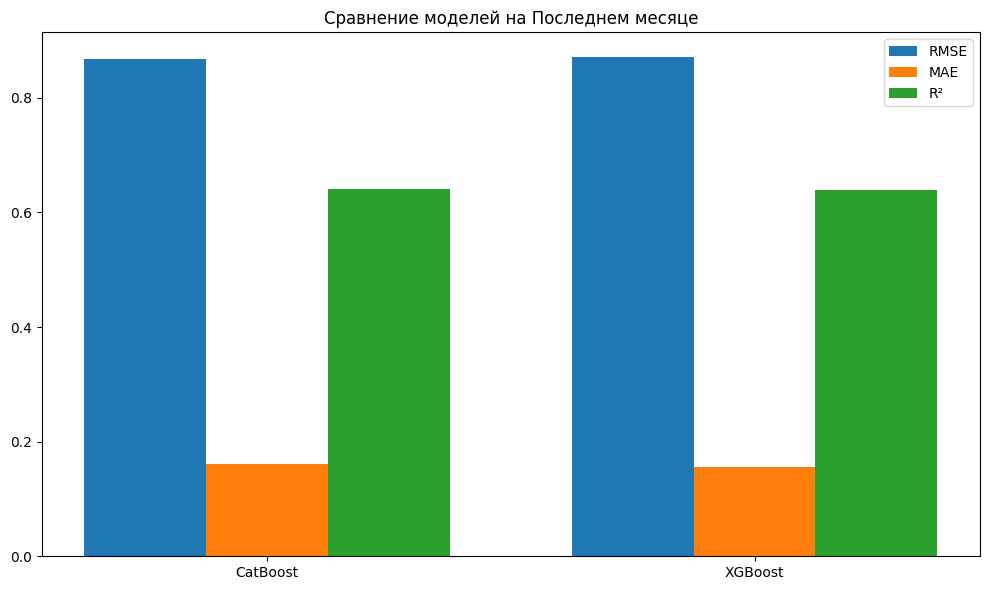

In [29]:
metrics_df = pd.DataFrame(comparison_data)
metrics_df.to_csv('artifacts/tables/metrics.csv', index=False)

plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_data))
width = 0.25
plt.bar(x - width, [d['RMSE'] for d in comparison_data], width, label='RMSE')
plt.bar(x, [d['MAE'] for d in comparison_data], width, label='MAE')
plt.bar(x + width, [d['R2'] for d in comparison_data], width, label='R²')
plt.xticks(x, [d['Model'] for d in comparison_data])
plt.legend()
plt.title('Сравнение моделей на Последнем месяце')
plt.tight_layout()
plt.savefig('artifacts/figures/model_comparison.png')
plt.show()

# Feature Importance

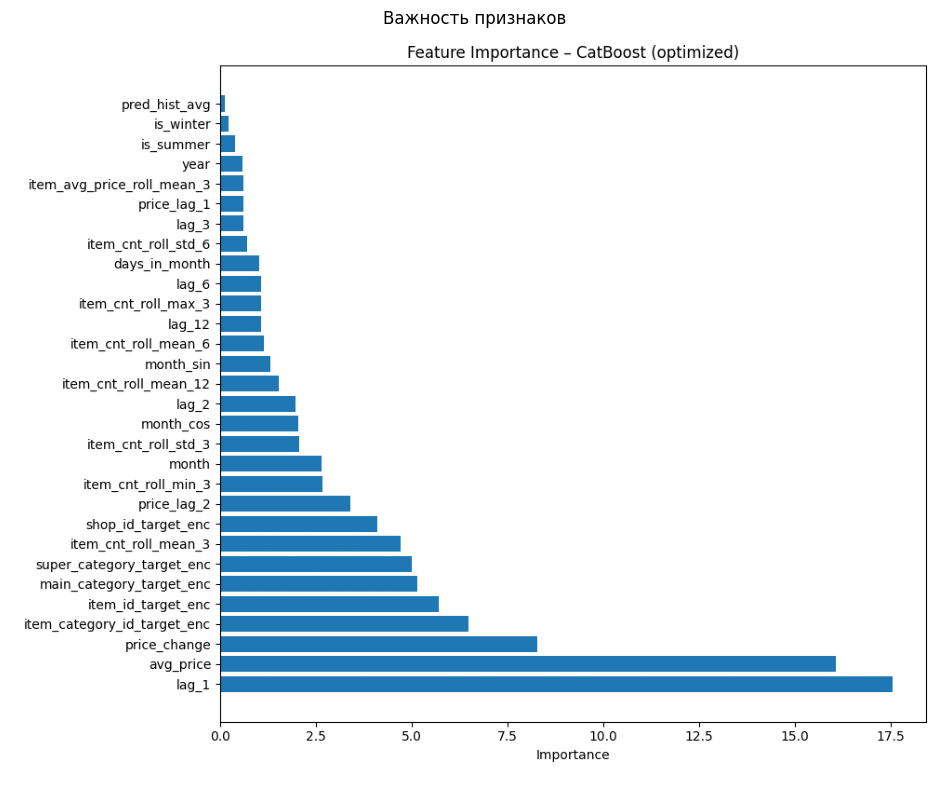

In [30]:
import matplotlib.image as mpimg

image_path = 'artifacts/figures/feature_importance_Catboost.png'

img = mpimg.imread(image_path)

fig = plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off')
plt.title('Важность признаков')
plt.show()

## SHAP

In [6]:
from catboost import CatBoostRegressor

model = CatBoostRegressor()
model.load_model('artifacts\models\catboost.cbm')

CatBoostRegressor(border_count=183, depth=10, iterations=600, l2_leaf_reg=0.8851428265, learning_rate=0.04465378952, loss_function='RMSE')

<Figure size 2000x600 with 0 Axes>

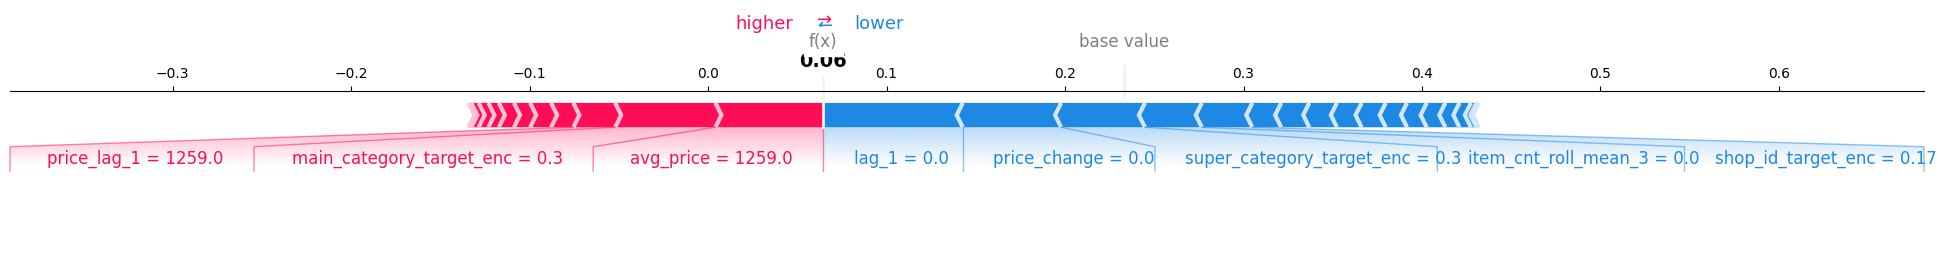

In [9]:
import shap

shap.initjs()
explainer = shap.TreeExplainer(model)
X_test = X_test_final.round(2)
shap_values_test = explainer(X_test)

fig = plt.figure(figsize=(20, 6))
shap.plots.force(shap_values_test[0], matplotlib=True, show=False)
plt.tight_layout()
plt.savefig('artifacts/figures/SHAP_force_plot.png', bbox_inches='tight', dpi=300)
plt.show()

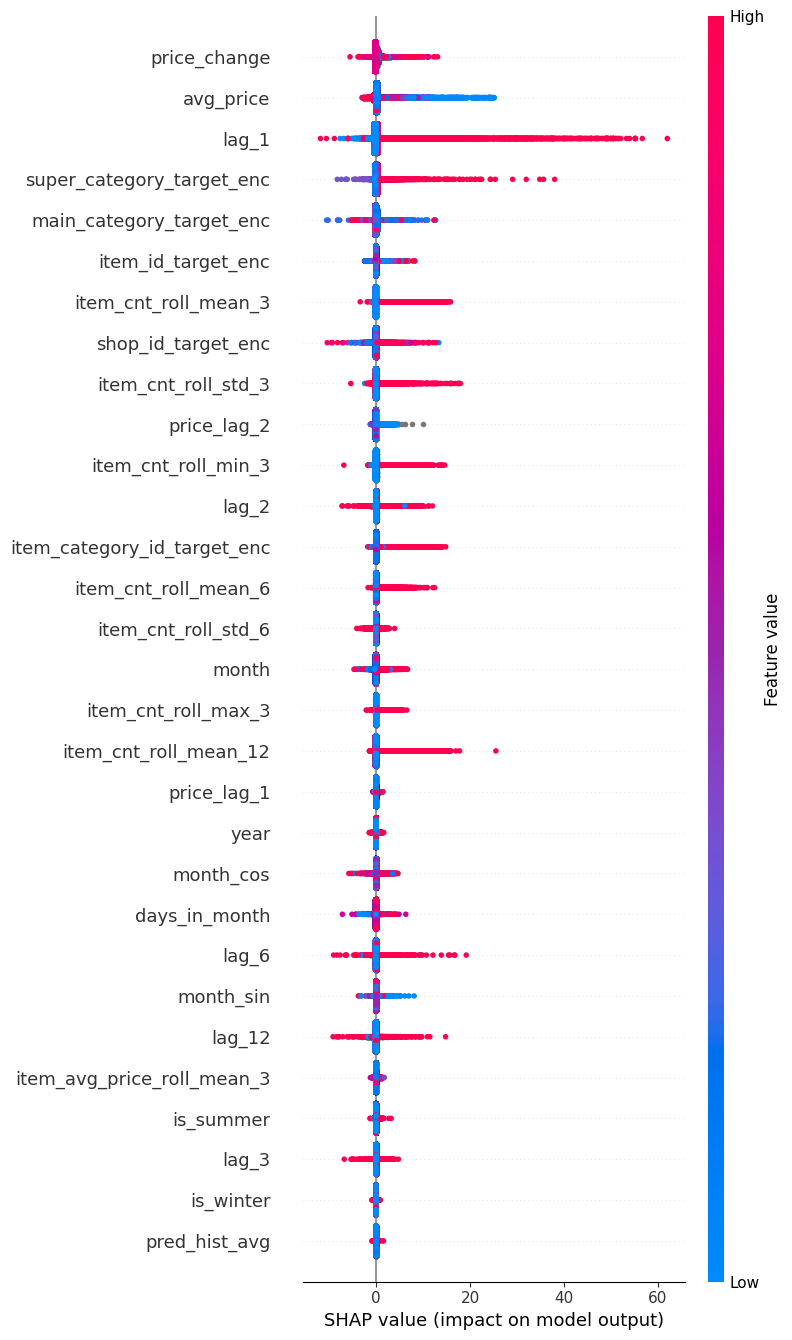

In [10]:
shap_values_train = explainer(X_train_final)
shap.summary_plot(shap_values_train, X_train_final, 
                  max_display=X_train_final.shape[1], show=False)

plt.savefig('artifacts/figures/SHAP_summary_plot.png', bbox_inches='tight')
plt.show()

# Анализ ошибок

## Actual VS Predicted

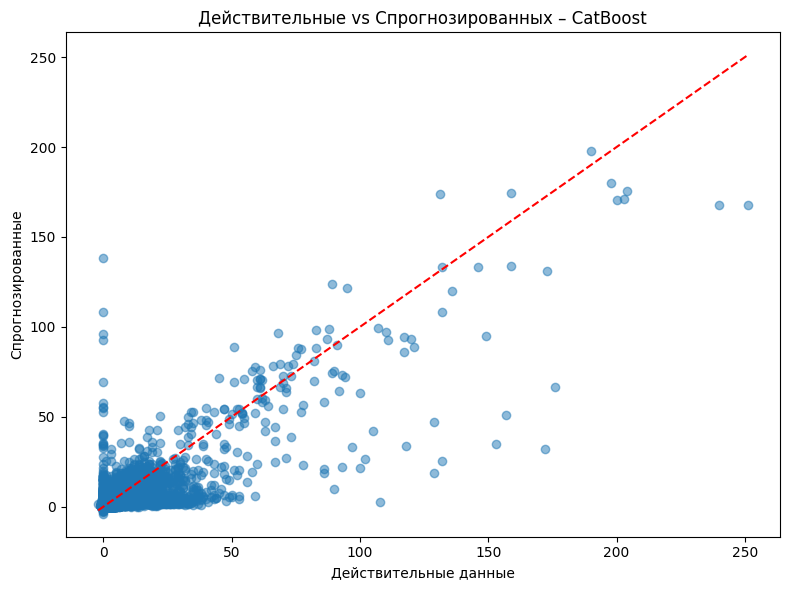

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_final, best_preds, alpha=0.5)
plt.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'r--')
plt.xlabel('Действительные данные')
plt.ylabel('Спрогнозированные')
plt.title(f'Действительные vs Спрогнозированных – {best_model_name}')
plt.tight_layout()
plt.savefig('artifacts/figures/actual_vs_predicted.png')
plt.show()

## Анализ остатков

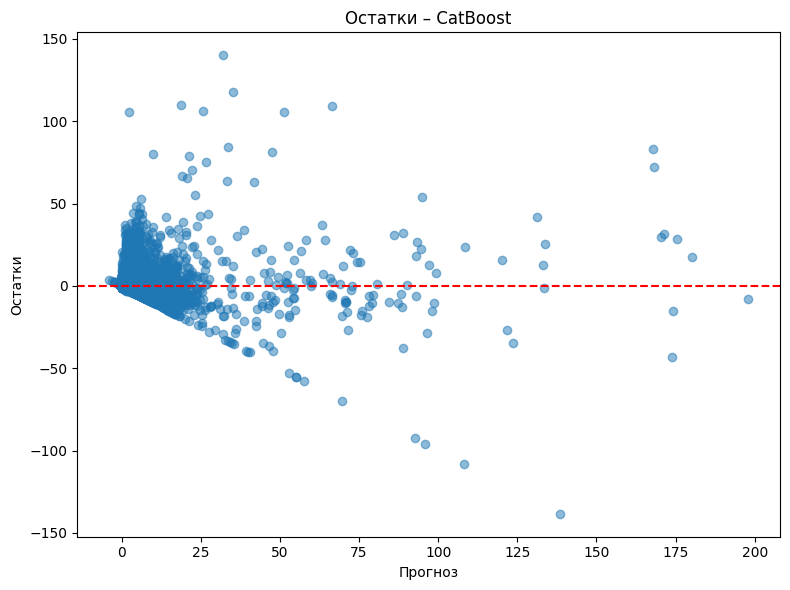

In [32]:
residuals = y_test_final - best_preds
plt.figure(figsize=(8, 6))
plt.scatter(best_preds, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Прогноз')
plt.ylabel('Остатки')
plt.title(f'Остатки – {best_model_name}')
plt.tight_layout()
plt.savefig('artifacts/figures/residuals.png')
plt.show()

## Распределение ошибок

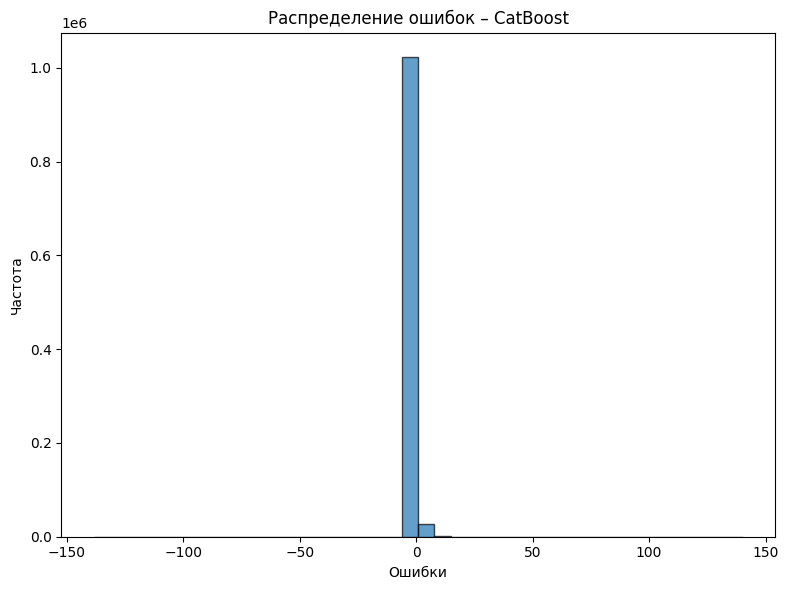

In [37]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=40, edgecolor='black', alpha=0.7)
plt.xlabel('Ошибки')
plt.ylabel('Частота')
plt.title(f'Распределение ошибок – {best_model_name}')
plt.tight_layout()
plt.savefig('artifacts/figures/error_distribution.png')
plt.show()